# Black-Litterman Backtest Example

This notebook demonstrates the backtest logic clearly.

`backtest.ipynb` is a Jupyter notebook file, so it cannot be imported directly like a Python module. To make the example runnable, the core equations and backtest functions are imported from `backtest_utils.py`, which is extracted from the notebook logic.

## 1. Setup

Import the reusable backtest functions and classes. The portfolio optimization in `backtest_utils.py` is now solved with `cvxpy`, so make sure `cvxpy` is installed in the notebook environment.

In [1]:
import cvxpy as cp
import numpy as np
import pandas as pd

from backtest_utils import (
    BlackLitterman,
    PerformanceMetrics,
    RollingWindowBacktest,
    get_standard_params,
    get_standard_views,
    run_experiment,
    run_experiment_improve_omega_only,
    run_experiment_improve_sigma_only,
)

## 2. Load Return Data

In [2]:
returns = pd.read_csv('etf_returns.csv', index_col=0, parse_dates=True)
returns.index = pd.to_datetime(returns.index)

print(f'Data shape: {returns.shape}')
print(f'Assets: {list(returns.columns)}')
print(f'Date range: {returns.index.min().date()} to {returns.index.max().date()}')
returns.head()

Data shape: (2764, 10)
Assets: ['EEM', 'EFA', 'IWM', 'QQQ', 'SPY', 'TLT', 'VNQ', 'XLE', 'XLK', 'XLV']
Date range: 2015-01-05 to 2025-12-30


,EEM,EFA,IWM,QQQ,SPY,TLT,VNQ,XLE,XLK,XLV
date,,,,,,,,,,
2015-01-05,-0.017797,-0.023605,-0.013369,-0.014668,-0.018059,0.015709,0.005473,-0.041368,-0.015265,-0.005100
2015-01-06,-0.004202,-0.011327,-0.017300,-0.013408,-0.009419,0.018018,0.009919,-0.014690,-0.012058,-0.003369
2015-01-07,0.021624,0.011115,0.012315,0.012891,0.012461,-0.001976,0.015331,0.002129,0.008469,0.023513
2015-01-08,0.017036,0.013530,0.016963,0.019140,0.017745,-0.013243,0.003775,0.022449,0.021981,0.017085
2015-01-09,-0.003299,-0.004839,-0.009604,-0.006583,-0.008013,0.010953,0.000470,-0.007925,-0.003142,-0.008894


## 3. One Rebalance Step: Show the Core BL Logic

This cell shows the exact logic inside one rebalance date:

1. Use the training window to estimate `mu` and `sigma`.
2. Generate views `P`, `q`, and `omega`.
3. Use Black-Litterman to get posterior return and covariance.
4. Optimize the portfolio weights.

In [3]:
train_window = 252 * 3
train_data = returns.iloc[:train_window]

mu, sigma = get_standard_params(train_data)
P, q, omega = get_standard_views(train_data)
market_weights = np.full(returns.shape[1], 1 / returns.shape[1])

bl = BlackLitterman(market_weights=market_weights, cov_matrix=sigma, tau=0.05)
mu_post, sigma_post = bl.update_with_views(P, q, omega)
weights, _, _ = bl.optimize_with_views(P, q, omega)

display(pd.Series(mu, index=returns.columns, name='prior_mu_annualized'))
display(pd.DataFrame(P, columns=returns.columns, index=['view_1', 'view_2']))
display(pd.Series(q, index=['view_1', 'view_2'], name='view_returns'))
display(pd.Series(mu_post, index=returns.columns, name='posterior_mu'))
display(pd.Series(weights, index=returns.columns, name='optimized_weights'))

EEM    0.113142
EFA    0.092645
IWM    0.113111
QQQ    0.168701
SPY    0.119593
TLT    0.029834
VNQ    0.055445
XLE    0.030955
XLK    0.181098
XLV    0.094798
Name: prior_mu_annualized, dtype: float64

,EEM,EFA,IWM,QQQ,SPY,TLT,VNQ,XLE,XLK,XLV
view_1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
view_2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


view_1    0.05
view_2    0.05
Name: view_returns, dtype: float64

EEM    0.032983
EFA    0.023777
IWM    0.022351
QQQ    0.021144
SPY    0.019830
TLT   -0.006895
VNQ    0.014795
XLE    0.034745
XLK    0.020843
XLV    0.017115
Name: posterior_mu, dtype: float64

EEM    9.436896e-16
EFA    2.914335e-16
IWM    0.000000e+00
QQQ    0.000000e+00
SPY    0.000000e+00
TLT    6.245005e-17
VNQ    0.000000e+00
XLE    1.000000e+00
XLK    0.000000e+00
XLV    0.000000e+00
Name: optimized_weights, dtype: float64

## 4. Full Rolling Backtest

Now run the same logic repeatedly in a rolling window backtest.

For each rebalance date, the engine does:

1. Train on the previous `train_window` returns.
2. Build BL views from the training data.
3. Compute new weights.
4. Apply those weights until the next rebalance date.

In [4]:
backtest = RollingWindowBacktest(
    returns_df=returns,
    train_window=252 * 3,
    rebalance_freq=252,
)

portfolio_values, portfolio_returns, weights_history = backtest.backtest_bl(
    get_params_func=get_standard_params,
    get_views_func=get_standard_views,
    tau=0.05,
)

metrics = PerformanceMetrics(
    portfolio_values=portfolio_values,
    returns=portfolio_returns,
    weights_history=weights_history,
).get_metrics()

pd.Series(metrics, name='standard_bl_metrics')

Annual Return        0.185586
Annual Volatility    0.277817
Sharpe Ratio         0.596028
Max Drawdown        -0.460068
Turnover             0.608938
VaR(95%)            -0.027182
Name: standard_bl_metrics, dtype: float64

## 5. Example: Improve Only Sigma

This example keeps the BL views unchanged and only changes the covariance matrix estimate.


TEST: Improved Sigma ONLY
P, q, omega use standard BL settings

BACKTEST RUNNING...
-> Strategy 1: Markowitz...
-> Strategy 2: Standard BL...
-> Strategy 3: Improved BL...

COMPARISON RESULTS:
                   Markowitz  Standard BL  Improved BL
Annual Return         0.1088       0.1856       0.0370
Annual Volatility     0.2592       0.2778       0.3063
Sharpe Ratio          0.3426       0.5960       0.0556
Max Drawdown         -0.3795      -0.4601      -0.6446
Turnover              0.1429       0.6089       0.8571
VaR(95%)             -0.0252      -0.0272      -0.0277


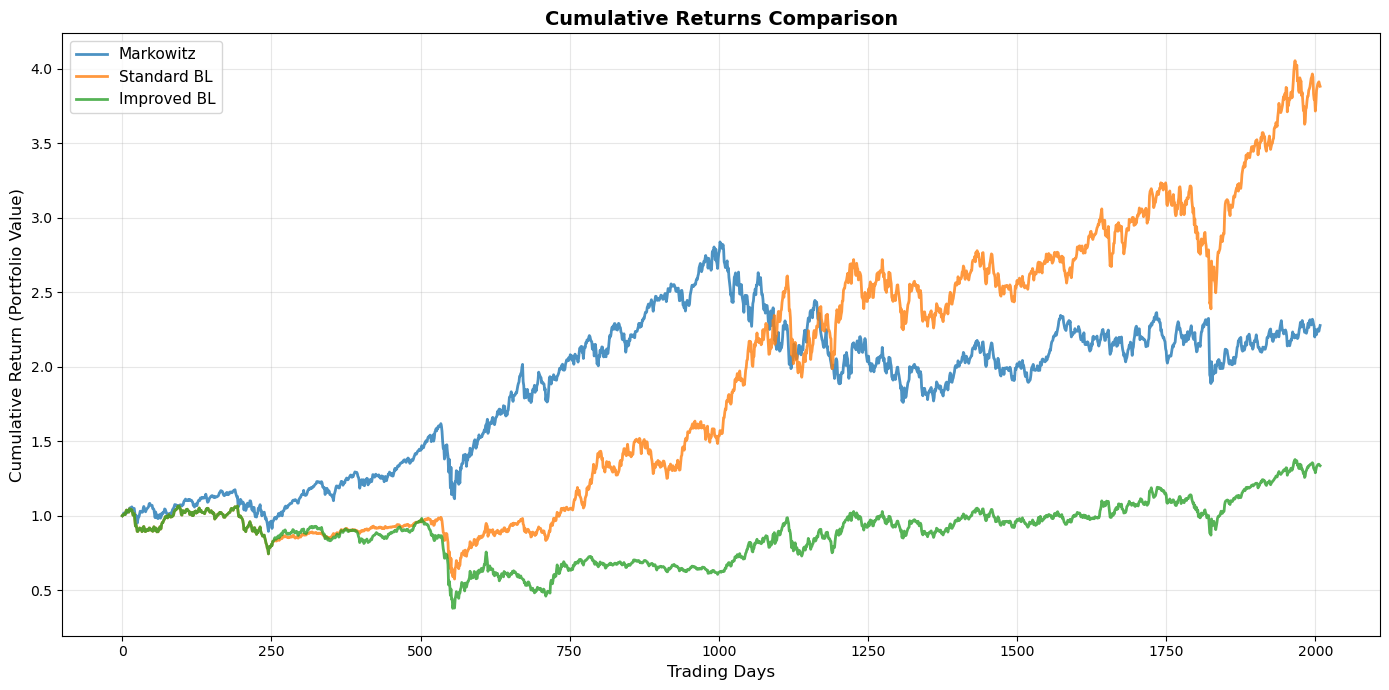

,Markowitz,Standard BL,Improved BL
Annual Return,0.108791,0.185586,0.037045
Annual Volatility,0.259194,0.277817,0.306344
Sharpe Ratio,0.342565,0.596028,0.055639
Max Drawdown,-0.379504,-0.460068,-0.644586
Turnover,0.142857,0.608938,0.857143
VaR(95%),-0.025210,-0.027182,-0.027748


In [5]:
demo_train = returns.iloc[:252 * 3]
standard_sigma = demo_train.cov().values
improved_sigma_demo = standard_sigma * 0.95

comparison_sigma, results_sigma = run_experiment_improve_sigma_only(
    returns_data=returns,
    improved_sigma=improved_sigma_demo,
    tau=0.05,
    train_window=252 * 3,
    rebalance_freq=252,
    plot=True,
)

comparison_sigma

## 6. Example: Improve Only Omega

This example keeps Sigma, `P`, and `q` unchanged and only changes the confidence matrix `omega`.


TEST: Improved Omega ONLY
Sigma, P, q use standard BL settings

BACKTEST RUNNING...
-> Strategy 1: Markowitz...
-> Strategy 2: Standard BL...
-> Strategy 3: Improved BL...

COMPARISON RESULTS:
                   Markowitz  Standard BL  Improved BL
Annual Return         0.1088       0.1856       0.2115
Annual Volatility     0.2592       0.2778       0.2774
Sharpe Ratio          0.3426       0.5960       0.6904
Max Drawdown         -0.3795      -0.4601      -0.3115
Turnover              0.1429       0.6089       0.7143
VaR(95%)             -0.0252      -0.0272      -0.0269


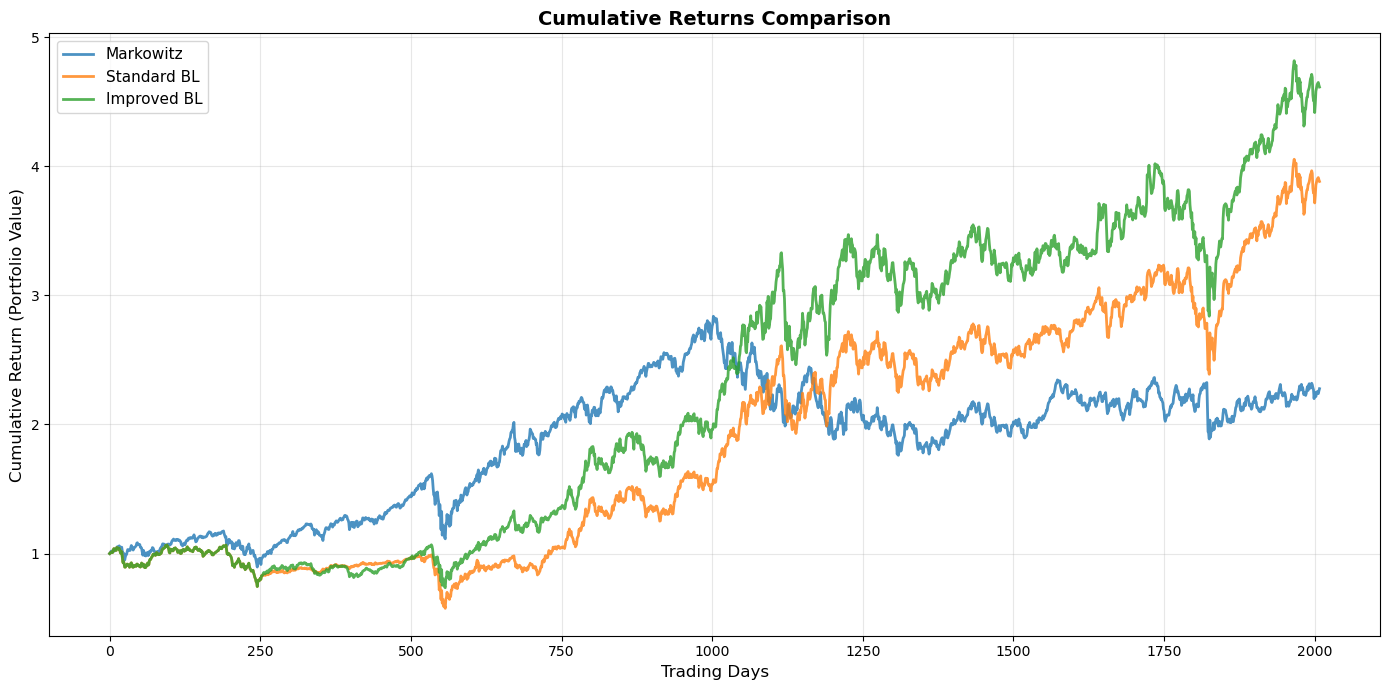

,Markowitz,Standard BL,Improved BL
Annual Return,0.108791,0.185586,0.211543
Annual Volatility,0.259194,0.277817,0.277425
Sharpe Ratio,0.342565,0.596028,0.690432
Max Drawdown,-0.379504,-0.460068,-0.311532
Turnover,0.142857,0.608938,0.714286
VaR(95%),-0.025210,-0.027182,-0.026865


In [6]:
demo_train = returns.iloc[:252 * 3]
P_demo, q_demo, _ = get_standard_views(demo_train)
demo_sigma = demo_train.cov().values
view_variance = np.array([np.dot(P_demo[i], np.dot(demo_sigma, P_demo[i])) for i in range(len(P_demo))])
standard_omega_demo = np.diag(view_variance * 0.05)
improved_omega_demo = standard_omega_demo * 0.7

comparison_omega, results_omega = run_experiment_improve_omega_only(
    returns_data=returns,
    improved_omega=improved_omega_demo,
    tau=0.05,
    train_window=252 * 3,
    rebalance_freq=252,
    plot=True,
)

comparison_omega

## 7. Example: Improve Sigma and Omega Together

This is the most general experiment interface.

BACKTEST RUNNING...
-> Strategy 1: Markowitz...
-> Strategy 2: Standard BL...
-> Strategy 3: Improved BL...

COMPARISON RESULTS:
                   Markowitz  Standard BL  Improved BL
Annual Return         0.1088       0.1856       0.0415
Annual Volatility     0.2592       0.2778       0.3039
Sharpe Ratio          0.3426       0.5960       0.0707
Max Drawdown         -0.3795      -0.4601      -0.6446
Turnover              0.1429       0.6089       0.8571
VaR(95%)             -0.0252      -0.0272      -0.0277


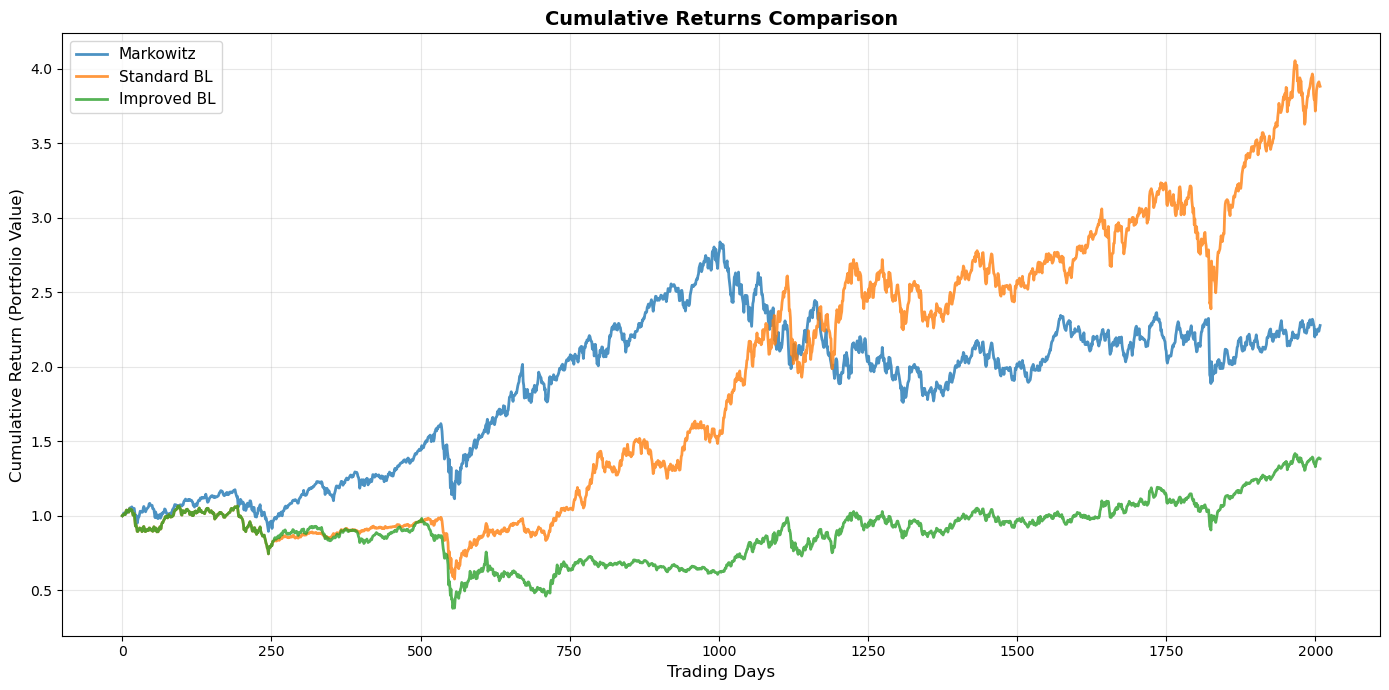

,Markowitz,Standard BL,Improved BL
Annual Return,0.108791,0.185586,0.041474
Annual Volatility,0.259194,0.277817,0.303918
Sharpe Ratio,0.342565,0.596028,0.070657
Max Drawdown,-0.379504,-0.460068,-0.644586
Turnover,0.142857,0.608938,0.857143
VaR(95%),-0.025210,-0.027182,-0.027723


In [7]:
comparison_both, results_both = run_experiment(
    returns_data=returns,
    custom_sigma=improved_sigma_demo,
    custom_omega=improved_omega_demo,
    tau=0.05,
    train_window=252 * 3,
    rebalance_freq=252,
    plot=True,
)

comparison_both